In [ ]:
# %pip install segmentation-models-pytorch
# %pip install --upgrade albumentations
# %pip install opencv-python
# %pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\owner\Desktop\rira\rira_pytorch\1114_success_outputunet_resnet18.pth
成功してるやつ！！上書きしない

In [ ]:

# %pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
# # 実行できない場合は管理者としてVScodeを立ち上げて実行

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.4.1%2Bcu121-cp311-cp311-win_amd64.whl (2444.9 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.19.1%2Bcu121-cp311-cp311-win_amd64.whl (5.8 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.4.1%2Bcu121-cp311-cp311-win_amd64.whl (4.1 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.7.1
    Uninstalling torch-2.7.1:
      Successfully uninstalled torch-2.7.1
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.22.1
    Uninstalling torchvision-0.22.1:
      Successfully uninstalled torchvision-0.22.1
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
print(torch.cuda.is_available())

True


これで多分いい感じなはず

In [2]:
# ライブラリ読み込み
import glob
import cv2
import numpy as np
import os
import os.path
 
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import segmentation_models_pytorch.utils as utils
 
import albumentations as albu
import matplotlib.pyplot as plt
from PIL import Image

c:\Users\orilab\Desktop\masumoto\smp\.smpenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.8 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [3]:
# データ確認用
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()

In [4]:
# テンソル化
def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')
 
# 前処理
def get_preprocessing(preprocessing_fn):
    _transform = [
            albu.Lambda(image=preprocessing_fn),
            albu.Lambda(image=to_tensor, mask=to_tensor),
        ]
    return albu.Compose(_transform)

In [5]:
# データ拡張
def get_training_augmentation():
    IMAGE_SIZE = 256
    train_transform = [
        albu.HorizontalFlip(p=0.5),
        albu.ShiftScaleRotate(scale_limit=0.5, rotate_limit=0, shift_limit=0.1, p=1, border_mode=0),
        albu.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, always_apply=True, border_mode=0),
        albu.RandomCrop(height=IMAGE_SIZE, width=IMAGE_SIZE, always_apply=True),
        albu.IAAAdditiveGaussianNoise(p=0.2),
        albu.IAAPerspective(p=0.5),
        albu.OneOf(
            [
                albu.CLAHE(p=1),
                albu.RandomBrightness(p=1),
                albu.RandomGamma(p=1),
            ],
            p=0.9,
        ),
        albu.OneOf(
            [
                albu.IAASharpen(p=1),
                albu.Blur(blur_limit=3, p=1),
                albu.MotionBlur(blur_limit=3, p=1),
            ],
            p=0.9,
        ),
        albu.OneOf(
            [
                albu.RandomContrast(p=1),
                albu.HueSaturationValue(p=1),
            ],
            p=0.9,
        ),
    ]
    return albu.Compose(train_transform)

In [6]:
test_mask_name = []

In [7]:
import numpy as np
import cv2

mask = cv2.imread(r'C:\\Users\\orilab\\Desktop\\masumoto\\smp\\data_split\\train\\mask\\00967.png', cv2.IMREAD_GRAYSCALE)
print(np.unique(mask))


[  0 127 255]


In [8]:
# データセット
class Dataset(BaseDataset):
    #CLASSES = ['background', 'SC']
    CLASSES = ['background', 'nerve', 'spinal']
    def __init__(
            self,
            images_dir,
            masks_dir,
            classes=None,
            augmentation=None,
            preprocessing=None,
    ):
        self.ids = sorted(os.listdir(images_dir))
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in self.ids]
        self.masks_fps = [os.path.join(masks_dir, image_id) for image_id in self.ids]
 
        # convert str names to class values on masks
        self.class_values = [0,127,255]
        # self.class_values = [classes.index(cls) for cls in classes]
 
        self.augmentation = augmentation
        self.preprocessing = preprocessing
 
    def __getitem__(self, i):
 
        # read data
        image = cv2.imread(self.images_fps[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                        
        # mask
        mask = cv2.imread(self.masks_fps[i], cv2.IMREAD_GRAYSCALE)        
        #mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        masks = np.array([(mask == v) for v in self.class_values])
        mask = np.stack(masks, axis=-1).astype('float')

        #test_mask_name.append(self.masks_fps[i])
        
        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
 
        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        return image, mask
 
    def __len__(self):
        return len(self.ids)

In [9]:
print("Torch version:",torch.__version__)

Torch version: 2.4.1+cu121


In [10]:
import torch
print(torch.cuda.is_available())

True


In [11]:
# モデルを宣言
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
#CLASSES = ['SC']
CLASSES = ['background', 'nerve', 'spinal']
#CLASSES = ['background', 'OPLL']
ACTIVATION = 'softmax2d'  # could be None for logits or 'softmax2d' for multicalss segmentation
# 'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnext50_32x4d', 'resnext101_32x4d', 
# ''resnext101_32x8d, 'resnext101_32x16d', 'resnext101_32x32d', 'resnext101_32x48d', 'dpn68', 'dpn68b', 
# 'dpn92', 'dpn98', 'dpn107', 'dpn131', 'vgg11', 'vgg11_bn', 'vgg13', 'vgg13_bn', 'vgg16', 'vgg16_bn', 
# 'vgg19', 'vgg19_bn', 'senet154', 'se_resnet50', 'se_resnet101', 'se_resnet152', 'se_resnext50_32x4d',
#  'se_resnext101_32x4d', 'densenet121', 'densenet169', 'densenet201', 'densenet161', 'inceptionresnetv2', 
# 'inceptionv4', 'efficientnet-b0', 'efficientnet-b1', 'efficientnet-b2', 'efficientnet-b3', 'efficientnet-b4', 
# 'efficientnet-b5', 'efficientnet-b6', 'efficientnet-b7', 'mobilenet_v2', 'xception', 'timm-efficientnet-b0', 
# 'timm-efficientnet-b1', 'timm-efficientnet-b2', 'timm-efficientnet-b3', 'timm-efficientnet-b4', 'timm-efficientnet-b5', 
# 'timm-efficientnet-b6', 'timm-efficientnet-b7', 'timm-efficientnet-b8', 'timm-efficientnet-l2', 'timm-tf_efficientnet_lite0',
#  'timm-tf_efficientnet_lite1', 'timm-tf_efficientnet_lite2', 'timm-tf_efficientnet_lite3', 'timm-tf_efficientnet_lite4', 
# 'timm-resnest14d', 'timm-resnest26d', 'timm-resnest50d', 'timm-resnest101e', 'timm-resnest200e', 'timm-resnest269e', 
# 'timm-resnest50d_4s2x40d', 'timm-resnest50d_1s4x24d', 'timm-res2net50_26w_4s', 'timm-res2net101_26w_4s', 'timm-res2net50_26w_6s', 
# 'timm-res2net50_26w_8s', 'timm-res2net50_48w_2s', 'timm-res2net50_14w_8s', 'timm-res2next50', 'timm-regnetx_002', 'timm-regnetx_004', 
# 'timm-regnetx_006', 'timm-regnetx_008', 'timm-regnetx_016', 'timm-regnetx_032', 'timm-regnetx_040', 'timm-regnetx_064', 'timm-regnetx_080', 
# 'timm-regnetx_120', 'timm-regnetx_160', 'timm-regnetx_320', 'timm-regnety_002', 'timm-regnety_004', 'timm-regnety_006', 'timm-regnety_008', 
# 'timm-regnety_016', 'timm-regnety_032', 'timm-regnety_040', 'timm-regnety_064', 'timm-regnety_080', 'timm-regnety_120', 'timm-regnety_160', 
# 'timm-regnety_320', 'timm-skresnet18', 'timm-skresnet34', 'timm-skresnext50_32x4d', 'timm-mobilenetv3_large_075', 'timm-mobilenetv3_large_100', 
# 'timm-mobilenetv3_large_minimal_100', 'timm-mobilenetv3_small_075', 'timm-mobilenetv3_small_100', 'timm-mobilenetv3_small_minimal_100', 'timm-gernet_s', 
# 'timm-gernet_m', 'timm-gernet_l', 'mit_b0', 'mit_b1', 'mit_b2', 'mit_b3', 'mit_b4', 'mit_b5', 'mobileone_s0', 'mobileone_s1', 'mobileone_s2', 'mobileone_s3', 'mobileone_s4'
#ACTIVATION = 'sigmoid'
DEVICE = 'cuda'
DECODER = 'unet'
# DeepLabV3Plusの場合、
# encoder_output_stride,decoder_channels,decoder_atrous_ratesが必要
# そのほか、(https://pypi.org/project/segmentation-models-pytorch/)を確認
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    classes=len(CLASSES),
    activation=ACTIVATION,
    )
model = model.to("cuda")

In [12]:
# train_dir = r'C:\\Users\\owner\\Desktop\\rira\\rira_pytorch\\1005train'
# val_dir = r'C:\\Users\\owner\\Desktop\\rira\\rira_pytorch\\1005val'

train_dir = r'C:\\Users\\orilab\\Desktop\\masumoto\\smp\\data_split\\train'
val_dir = r'C:\\Users\\orilab\\Desktop\\masumoto\\smp\\data_split\\val'
 
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
 
# データセットを作成
train_dataset = Dataset(
    os.path.join(train_dir, 'image'),
    os.path.join(train_dir, 'mask'),
    preprocessing=get_preprocessing(preprocessing_fn),
    classes=CLASSES,
)
valid_dataset = Dataset(
    os.path.join(val_dir, 'image'),
    os.path.join(val_dir, 'mask'),
    preprocessing=get_preprocessing(preprocessing_fn),
    classes=CLASSES,
)
 
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False, num_workers=0)

In [13]:
from PIL import Image
# files = glob.glob(r'C:\\Users\\owner\\Desktop\\rira\\rira_pytorch\\1005train\\mask\\*.png')
files = glob.glob("C:\\Users\\orilab\\Desktop\\masumoto\\smp\\data_split\\train\\mask\\*.png")
for i, file in enumerate(files): 
    image = Image.open(file) #画像の読み込み
    image = image.convert("P") #パレットモード（インデックスカラー）へ変換

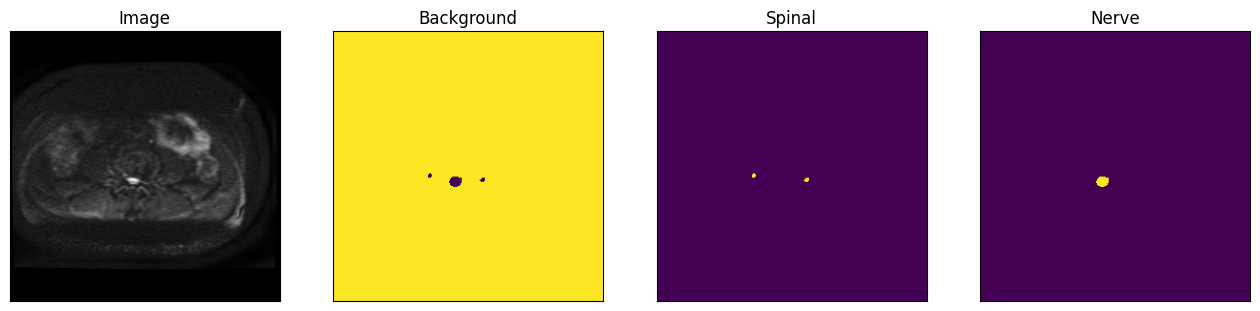

1.0


In [14]:
# データ確認
dataset = Dataset(os.path.join(train_dir, 'image'), os.path.join(train_dir, 'mask'), classes=['background', 'nerve', 'spinal'])
image, mask = dataset[42] # get some sample

visualize(
    image=image, 
    background=mask[..., 0].squeeze(),
    spinal=mask[..., 1].squeeze(),
    nerve=mask[..., 2].squeeze(),
)
print(
    mask[..., 2].squeeze().max()
)
"""
visualize(
    image=image, 
    background_mask=mask[..., 0].squeeze(),
    opll_mask=mask[..., 2].squeeze(),
)
"""
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()

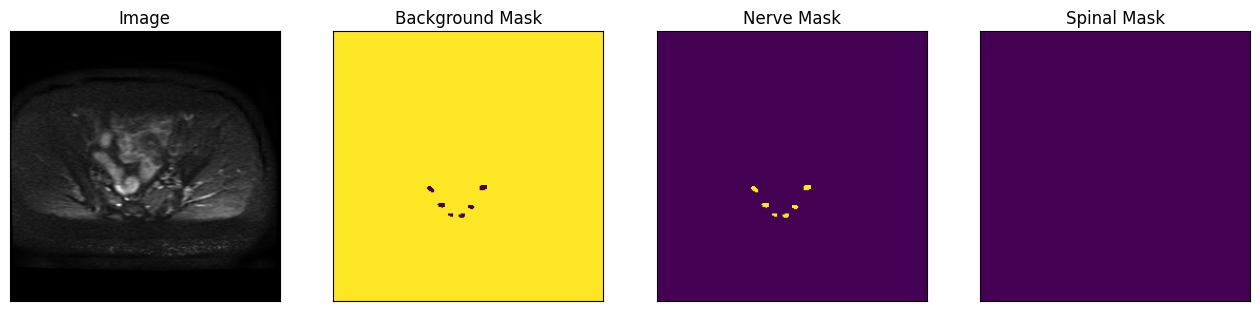

In [15]:
dataset = Dataset(os.path.join(train_dir, 'image'), os.path.join(train_dir, 'mask'), classes= ['background', 'nerve', 'spinal'])
for i in range(1):
    image, mask = dataset[i] # get some sample
    
    visualize(
        image=image, 
        background_mask=mask[..., 0].squeeze(),
        nerve_mask=mask[..., 1].squeeze(),
        spinal_mask=mask[..., 2].squeeze(),
    )
    """
    visualize(
        image=image, 
        background_mask=mask[..., 0].squeeze(),
        opll_mask=mask[..., 2].squeeze(),
    )
    """

In [ ]:
# # マルチクラス対応DiceLoss（クラス重みあり）を自作
# import torch
# import torch.nn.functional as F

# class MultiClassDiceLoss(torch.nn.Module):
#     def __init__(self, class_weights=None, eps=1e-7):
#         super().__init__()
#         self.class_weights = class_weights
#         self.eps = eps

#     def forward(self, pred, target):
#         """
#         pred: (B, C, H, W)  → Softmax済み前提
#         target: (B, C, H, W) → One-hot形式
#         """
#         pred = F.softmax(pred, dim=1)
#         target = target.float()

#         dims = (0, 2, 3)  # reduce over batch, height, width
#         intersection = torch.sum(pred * target, dims)
#         cardinality = torch.sum(pred + target, dims)
#         dice_loss = 1 - (2. * intersection + self.eps) / (cardinality + self.eps)

#         if self.class_weights is not None:
#             dice_loss = dice_loss * self.class_weights

#         return dice_loss.mean()


In [17]:
# マルチクラス対応DiceLoss（クラス重みあり）を自作
import torch
import torch.nn.functional as F
class MultiClassDiceLoss(torch.nn.Module):
    def __init__(self, class_weights=None, eps=1e-7):
        super().__init__()
        self.class_weights = class_weights
        self.eps = eps
        self.__name__ = 'MultiClassDiceLoss'  # ← ここを追加！

    def forward(self, pred, target):
        pred = F.softmax(pred, dim=1)
        target = target.float()

        dims = (0, 2, 3)
        intersection = torch.sum(pred * target, dims)
        cardinality = torch.sum(pred + target, dims)
        dice_loss = 1 - (2. * intersection + self.eps) / (cardinality + self.eps)

        if self.class_weights is not None:
            dice_loss = dice_loss * self.class_weights

        return dice_loss.mean()


In [18]:
from segmentation_models_pytorch.utils.metrics import Fscore

weights = torch.tensor([0.1, 1.5, 0.5], device=DEVICE)
loss = MultiClassDiceLoss(class_weights=weights)

# 最適化関数
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=0.001),
])

# 精度確認指標（変更不要）
metrics = [
    Fscore(threshold=0.5),
]

# 最適化関数
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=0.001),
])

In [19]:
# 1Epochトレイン用
train_epoch = smp.utils.train.TrainEpoch(
    model,
    loss=loss,
    metrics=metrics,
    optimizer=optimizer,
    device=DEVICE,
    verbose=True,
)
valid_epoch = smp.utils.train.ValidEpoch(
    model,
    loss=loss,
    metrics=metrics,
    device=DEVICE,
    verbose=True,
)

In [20]:
import os
from datetime import datetime
import traceback

# モデル保存先フォルダ
save_dir = r"C:\Users\orilab\Desktop\masumoto\smp\checkpoints"
os.makedirs(save_dir, exist_ok=True)

# 日付文字列（例: 20240623_1420）
today_str = datetime.now().strftime('%Y%m%d_%H%M')
max_score = 0

# ログ保存用リスト
x_epoch_data = []
train_dice_loss = []
train_f_score = []
valid_dice_loss = []
valid_f_score = []

# エポックループ
for i in range(0, 200):
    print(f'\nEpoch: {i}')
    try:
        train_logs = train_epoch.run(train_loader)
        val_logs = valid_epoch.run(valid_loader)
        print('trying')
    except Exception as e:
        print("例外が発生しました:")
        traceback.print_exc()
        continue  # 次のエポックへスキップ

    # ログ保存
    x_epoch_data.append(i)
    train_dice_loss.append(train_logs['MultiClassDiceLoss'])
    train_f_score.append(train_logs['fscore'])
    valid_dice_loss.append(val_logs['MultiClassDiceLoss'])
    valid_f_score.append(val_logs['fscore'])

    # モデル保存（val_fscoreが更新された場合）
    if max_score < val_logs['fscore']:
        max_score = val_logs['fscore']
        filename = f"{today_str}_{str(DECODER)}_{str(ENCODER)}.pth"
        torch.save(model, os.path.join(save_dir, filename))
        print('Model saved!')

    # 20エポック後に学習率を下げる
    if i == 20:
        optimizer.param_groups[0]['lr'] = 1e-4
        print('Decrease decoder learning rate to 1e-4!')



Epoch: 0
valid: 100%|██████████| 42/42 [00:04<00:00,  9.54it/s, MultiClassDiceLoss - 0.6731, fscore - 0.9966]
trying
Model saved!

Epoch: 1
valid: 100%|██████████| 42/42 [00:01<00:00, 31.57it/s, MultiClassDiceLoss - 0.6733, fscore - 0.9958]
trying

Epoch: 2
valid: 100%|██████████| 42/42 [00:01<00:00, 31.28it/s, MultiClassDiceLoss - 0.6728, fscore - 0.9946]
trying

Epoch: 3
valid: 100%|██████████| 42/42 [00:01<00:00, 31.14it/s, MultiClassDiceLoss - 0.6728, fscore - 0.9921]
trying

Epoch: 4
valid: 100%|██████████| 42/42 [00:01<00:00, 31.46it/s, MultiClassDiceLoss - 0.6729, fscore - 0.996] 
trying

Epoch: 5
valid: 100%|██████████| 42/42 [00:01<00:00, 31.27it/s, MultiClassDiceLoss - 0.6729, fscore - 0.9961]
trying

Epoch: 6
valid: 100%|██████████| 42/42 [00:01<00:00, 31.14it/s, MultiClassDiceLoss - 0.6729, fscore - 0.9963]
trying

Epoch: 7
valid: 100%|██████████| 42/42 [00:01<00:00, 31.17it/s, MultiClassDiceLoss - 0.6729, fscore - 0.9967]
trying
Model saved!

Epoch: 8
valid: 100%|████████

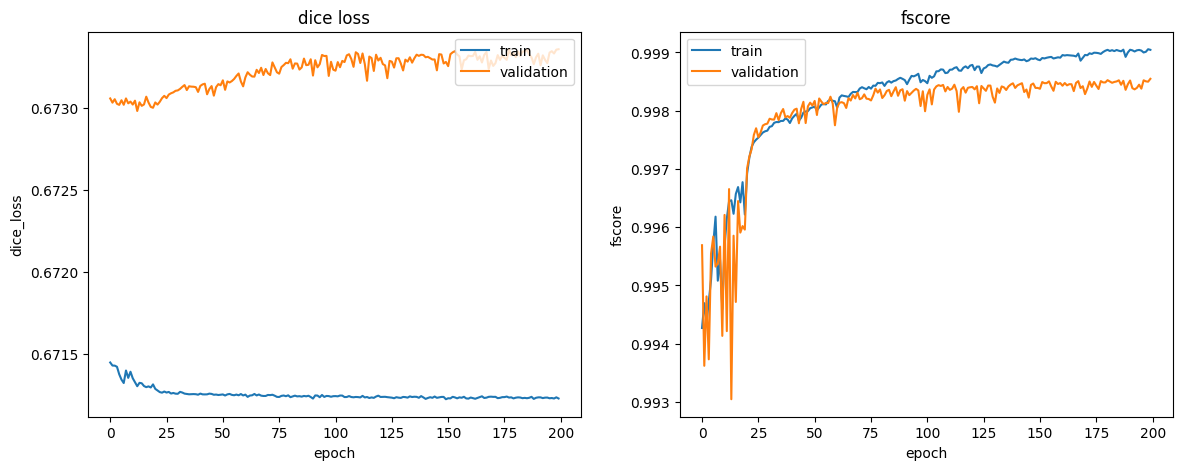

In [30]:
# loss, IoUを可視化
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
line1, = ax1.plot(x_epoch_data,train_dice_loss,label='train') 
line2, = ax1.plot(x_epoch_data,valid_dice_loss,label='validation')
ax1.set_title("dice loss")
ax1.set_xlabel('epoch')
ax1.set_ylabel('dice_loss')
ax1.legend(loc='upper right')

ax2 = fig.add_subplot(1, 2, 2)
line1, = ax2.plot(x_epoch_data,train_f_score,label='train')
line2, = ax2.plot(x_epoch_data,valid_f_score,label='validation') 
ax2.set_title("fscore")
ax2.set_xlabel('epoch')
ax2.set_ylabel('fscore')
ax2.legend(loc='upper left')

plt.show()

In [31]:
# load best saved checkpoint
best_model = torch.load(f"C:\\Users\\orilab\\Desktop\\masumoto\\smp\\checkpoints\\20250623_2058_unet_resnet34.pth")
# best_model = torch.load('C:/Users/owner/Desktop/rira/rira_pytorch/1114_success_outputunet_resnet18.pth')


C:\Users\orilab\AppData\Local\Temp\ipykernel_36324\2295192587.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model = torch.load(f"C:\\Users\\orilab\\Desktop\\masum

In [32]:
#test_dir = 'D:/DCMseg/test'
test_dir = 'C:\\Users\\orilab\\Desktop\\masumoto\\smp\\data_split\\test'
# create test dataset
test_dataset = Dataset(
    os.path.join(test_dir, 'image'),
    os.path.join(test_dir, 'mask'),
    preprocessing=get_preprocessing(preprocessing_fn),
    classes=['background', 'nerve', 'spinal'],
)
test_dataloader = DataLoader(test_dataset, batch_size=6, shuffle=False, num_workers=0)

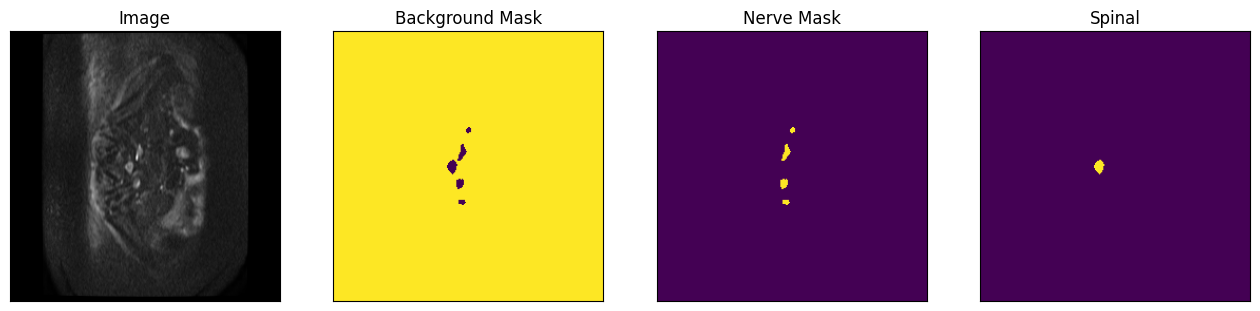

'\nvisualize(\n    image=image, \n    background_mask=mask[..., 0].squeeze(),\n    opll_mask=mask[..., 2].squeeze(),\n)\n'

In [33]:
dataset = Dataset(os.path.join(test_dir, 'image'), os.path.join(test_dir, 'mask'), classes=['background', 'nerve', 'spinal'])
image, mask = dataset[78] # get some sample

base_name = 'image'
file_names = [f'{base_name}_{i}.png' for i in range(1, 6)] 
num = 0

# for i in dataset:
#     num += 1
#     _filename = 'C:/Users/owner/Desktop/rira/rira_pytorch/output2/test'
#     filename = _filename + str(num) + ".png"
#     cv2.imwrite(filename, mask[..., 1].squeeze())
#     # print(mask[..., 1].squeeze().shape)

visualize(
    image=image, 
    background_mask=mask[..., 0].squeeze(),   #0か1
    nerve_mask=mask[..., 1].squeeze(),
    spinal=mask[..., 2].squeeze(),
)
"""
visualize(
    image=image, 
    background_mask=mask[..., 0].squeeze(),
    opll_mask=mask[..., 2].squeeze(),
)
"""

In [35]:
test_epoch = smp.utils.train.ValidEpoch(
    model=best_model,
    loss=loss,
    metrics=metrics,
    device=DEVICE,
)

logs = test_epoch.run(test_dataloader)
print(logs['MultiClassDiceLoss'])
print(logs['fscore'])

valid: 100%|██████████| 57/57 [00:01<00:00, 35.25it/s, MultiClassDiceLoss - 0.6728, fscore - 0.9984]
0.6727713
0.9984294


In [36]:
# test dataset without transformations for image visualization
test_dataset_vis = Dataset(
    os.path.join(test_dir, 'image'), os.path.join(test_dir, 'mask'),
    classes= ['background', 'nerve', 'spinal'],
)

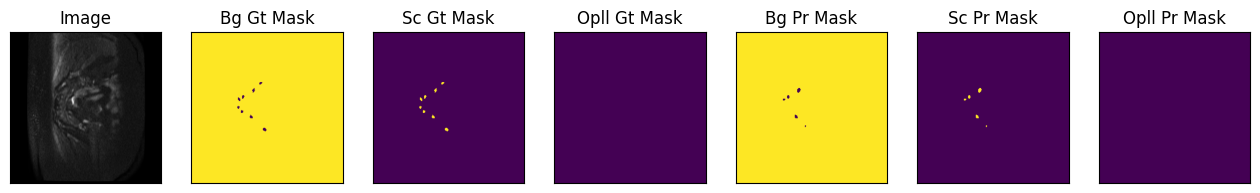

'\nvisualize(\n    image=image_vis, \n    bg_gt_mask=gt_mask[..., 0].squeeze(),\n    opll_gt_mask=gt_mask[..., 1].squeeze(),\n    bg_pr_mask=pr_mask[..., 0].squeeze(),\n    opll_pr_mask=pr_mask[..., 1].squeeze(),\n)\n'

In [47]:
# 1つだけ可視化
n = 55
image_vis = test_dataset_vis[n][0].astype('uint8')
image, gt_mask = test_dataset[n]

gt_mask = gt_mask.squeeze()
gt_mask = gt_mask.transpose(1, 2, 0)
   
x_tensor = torch.from_numpy(image).to(DEVICE).unsqueeze(0)
pr_mask = best_model.predict(x_tensor)
pr_mask = (pr_mask.squeeze().cpu().numpy().round())
pr_mask = pr_mask.transpose(1, 2, 0)



visualize(
    image=image_vis, 
    bg_gt_mask=gt_mask[..., 0].squeeze(),
    sc_gt_mask=gt_mask[..., 1].squeeze(),
    opll_gt_mask=gt_mask[..., 2].squeeze(),
    bg_pr_mask=pr_mask[..., 0].squeeze(),
    sc_pr_mask=pr_mask[..., 1].squeeze(),
    opll_pr_mask=pr_mask[..., 2].squeeze(),
)
"""
visualize(
    image=image_vis, 
    bg_gt_mask=gt_mask[..., 0].squeeze(),
    opll_gt_mask=gt_mask[..., 1].squeeze(),
    bg_pr_mask=pr_mask[..., 0].squeeze(),
    opll_pr_mask=pr_mask[..., 1].squeeze(),
)
"""

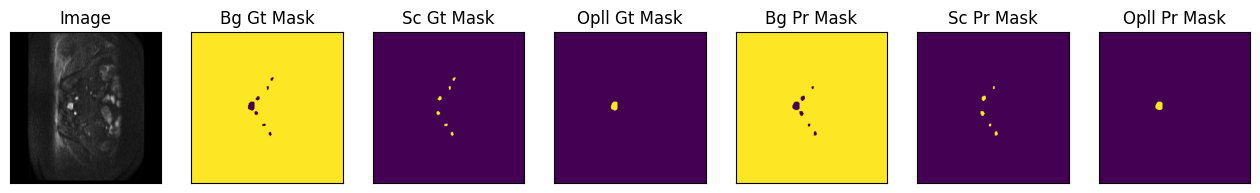

In [38]:
n = 70
image_vis = test_dataset_vis[n][0].astype('uint8')
image, gt_mask = test_dataset[n]

gt_mask = gt_mask.squeeze().transpose(1, 2, 0)

x_tensor = torch.from_numpy(image).to(DEVICE).unsqueeze(0)

with torch.no_grad():
    pr_mask = best_model(x_tensor)                  # shape: [1, 3, H, W]
    pr_mask = torch.softmax(pr_mask, dim=1)         # Softmaxでクラス確率化
    pr_mask = (pr_mask > 0.5).float()               # しきい値で2値化
    pr_mask = pr_mask.squeeze().cpu().numpy().transpose(1, 2, 0)  # shape: [H, W, 3]

visualize(
    image=image_vis,
    bg_gt_mask=gt_mask[..., 0].squeeze(),
    sc_gt_mask=gt_mask[..., 1].squeeze(),
    opll_gt_mask=gt_mask[..., 2].squeeze(),
    bg_pr_mask=pr_mask[..., 0].squeeze(),
    sc_pr_mask=pr_mask[..., 1].squeeze(),
    opll_pr_mask=pr_mask[..., 2].squeeze(),
)


In [39]:
for i, cls_name in enumerate(["Bg", "Nerve", "Spinal"]):
    print(f"{cls_name} mask - unique values:", np.unique(pr_mask[..., i]))



Bg mask - unique values: [0. 1.]
Nerve mask - unique values: [0. 1.]
Spinal mask - unique values: [0. 1.]


In [40]:
from torchvision import transforms

In [41]:
def dice_coefficient(image_path, predict_path):
    image = cv2.imread(image_path)
    predict = cv2.imread(predict_path)
    prediction_label = (predict == 255)
    target_label = (image == 255)

    intersection = np.logical_and(prediction_label, target_label)
    tp = np.sum(intersection)
    fp = np.sum(prediction_label) - tp
    fn = np.sum(target_label) - tp
    tn = np.sum((prediction_label == 0) & (target_label == 0))
    # Accuracy（正解率）
    accuracy = (tp + tn) / (tp + fp + fn + tn)

    # Recall（再現率）またはTrue Positive Rate（TPR）
    recall = tp / (tp + fn)
    # Dice係数を計算
    dice = (2.0 * tp) / (2.0 * tp + fp + fn)
    precision = tp / (tp + fp)

    # print('accuracy', accuracy)
    # print('recall', recall)
    # print('Dice', dice)      
    # print('precision', precision)
    return accuracy, recall, dice, precision

In [ ]:
# %pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\orilab\AppData\Local\Temp\ipykernel_36324\2782407037.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
C:\Users\orilab\AppData\Local\Temp\ipykernel_36324\2782407037.py:16: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)
C:\Users\orilab\AppData\Local\Temp\ipykernel_36324\2782407037.py:18: RuntimeWarning: invalid value encountered in scalar divide
  dice = (2.0 * tp) / (2.0 * tp + fp + fn)


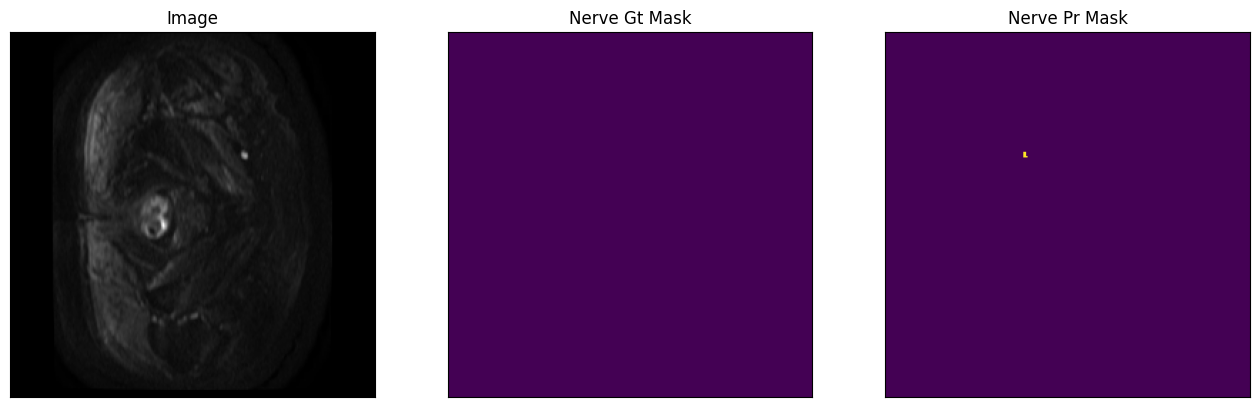

nerve_dice :  0.0 spinal_dice :  nan


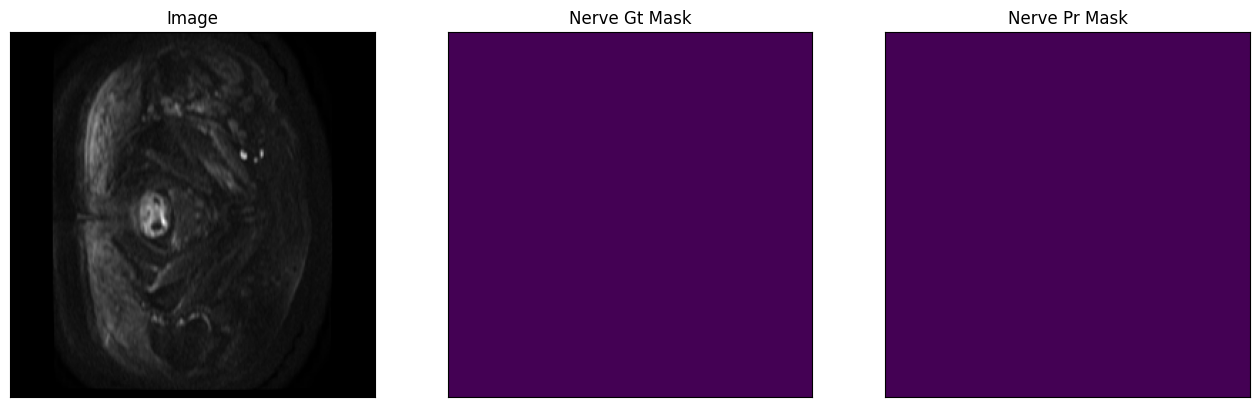

nerve_dice :  nan spinal_dice :  nan


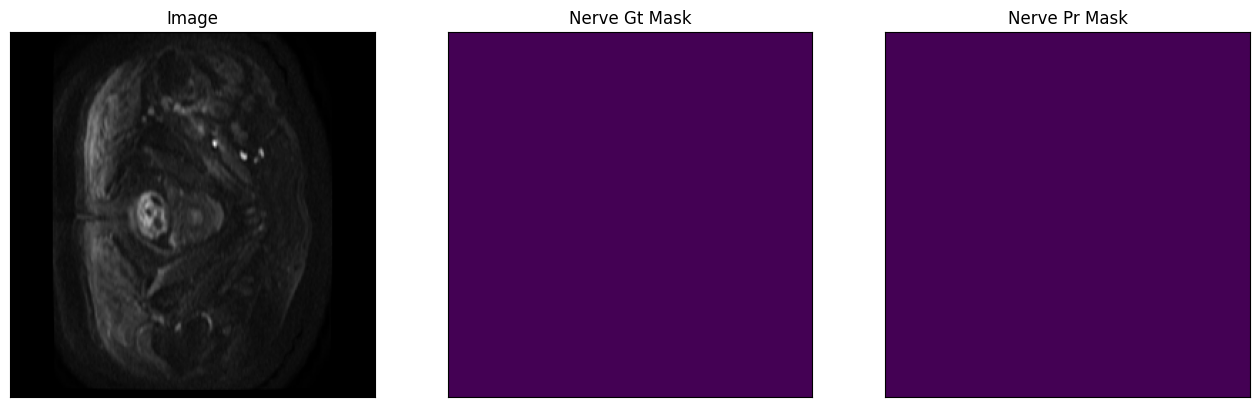

nerve_dice :  nan spinal_dice :  nan


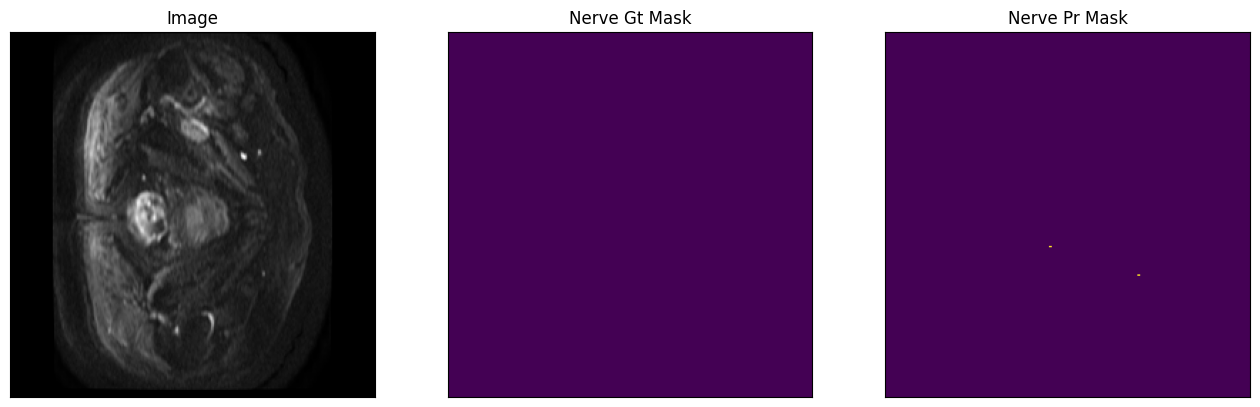

nerve_dice :  0.0 spinal_dice :  nan


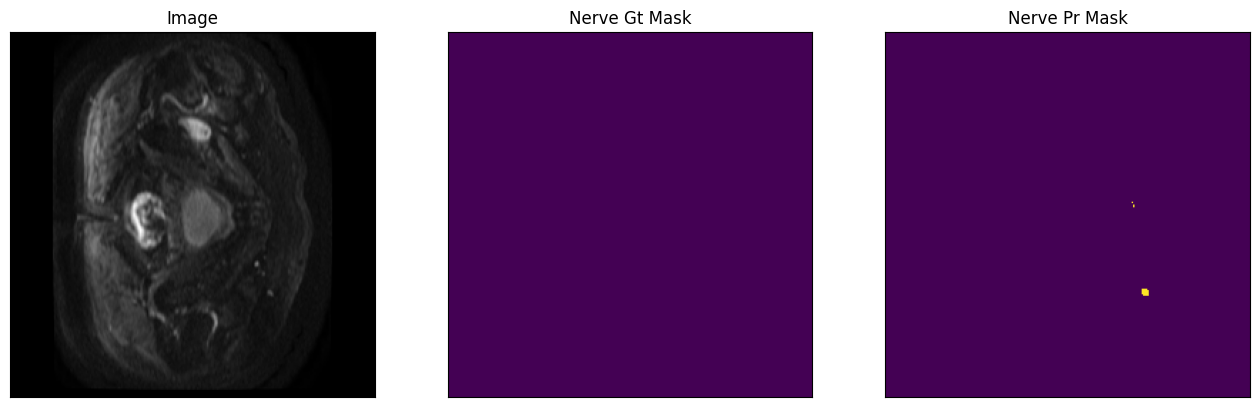

nerve_dice :  0.0 spinal_dice :  0.0


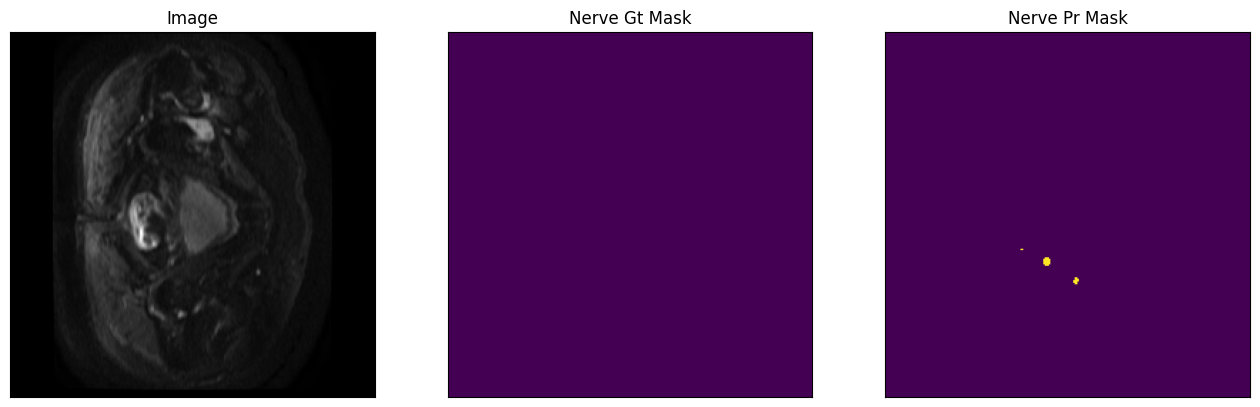

nerve_dice :  0.0 spinal_dice :  nan


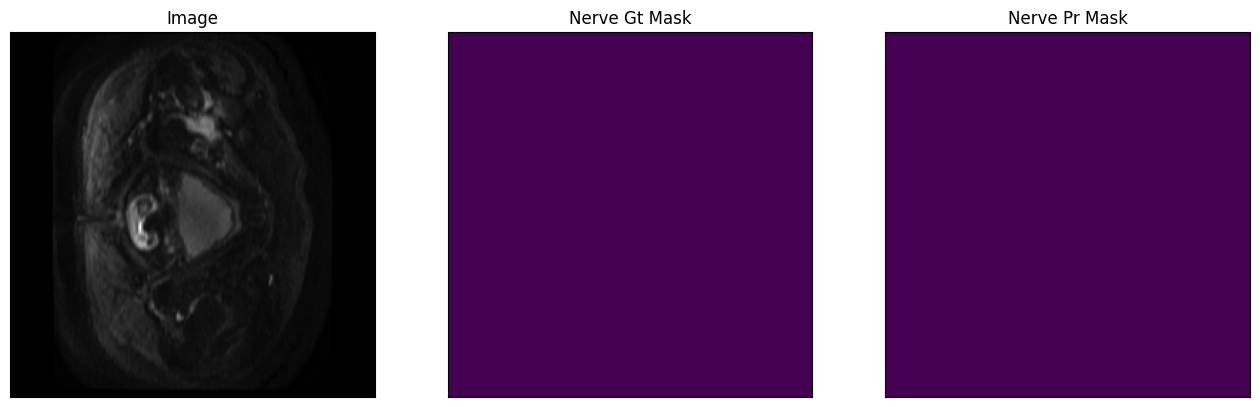

nerve_dice :  nan spinal_dice :  nan


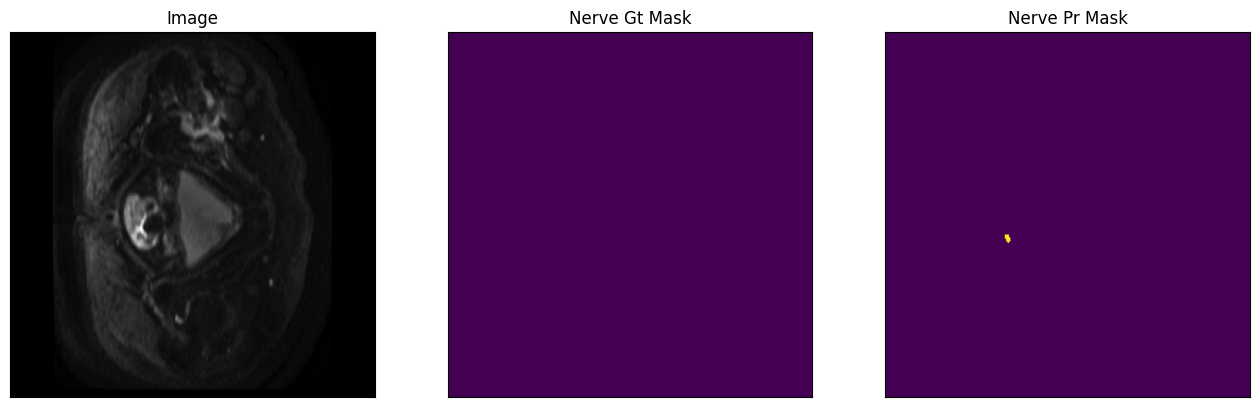

nerve_dice :  0.0 spinal_dice :  nan


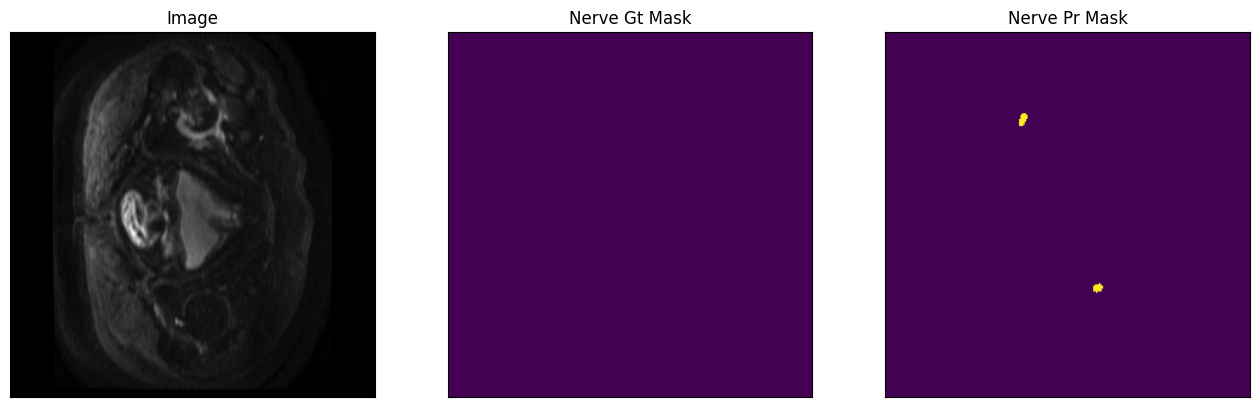

nerve_dice :  0.0 spinal_dice :  nan


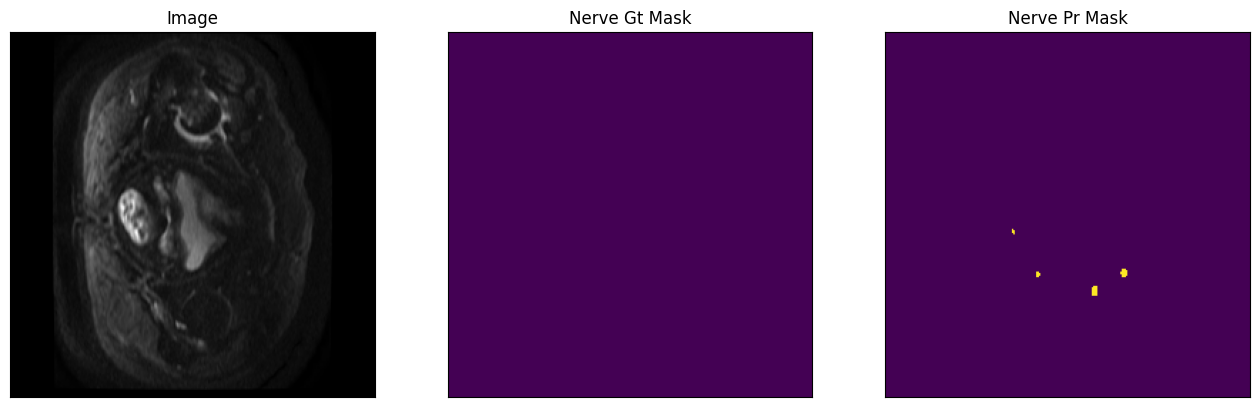

nerve_dice :  0.0 spinal_dice :  nan


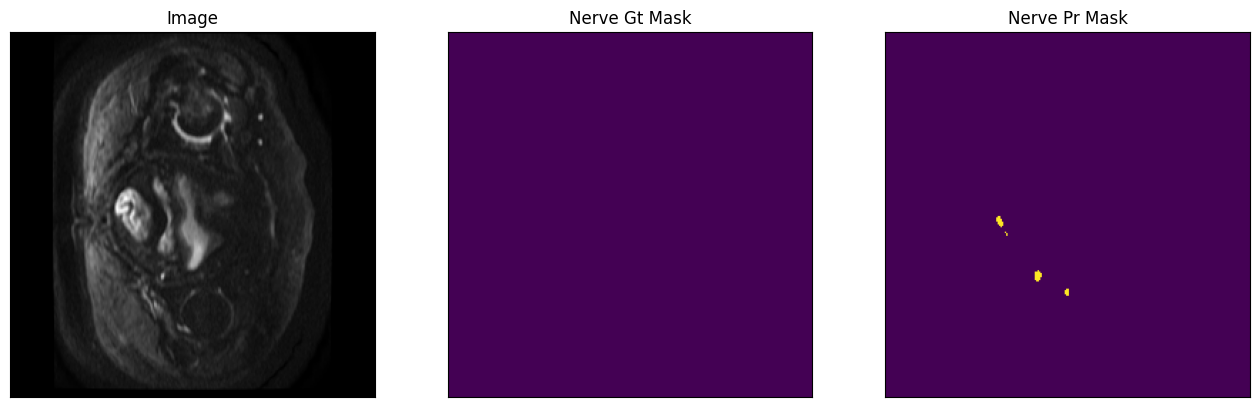

nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  0.0
nerve_dice :  0.0 spinal_dice :  nan
nerve_dice :  0.0 spinal_dice :  0.0
nerve_dice :  0.16279069767441862 spinal_dice :  nan
nerve_dice :  0.31521739130434784 spinal_dice :  nan
nerve_dice :  0.354978354978355 spinal_dice :  nan
nerve_dice :  0.6788990825688074 spinal_dice :  nan
nerve_dice :  0.6592797783933518 spinal_dice :  nan
nerve_dice :  0.7713498622589532 spinal_dice :  nan
nerve_dice :  0.6228070175438597 spinal_dice :  nan
nerve_dice :  0.6468085106382979 spinal_dice :  nan
nerve_dice :  0.6699029126213593 spinal_dice :  nan
nerve_dice :  0.7614213197969543 spinal_dice :  nan
nerve_dice :  0.6826666666666666 spinal_dice :  nan
nerve_dice :  0.24267782426778242 spinal_dice :  0.0
nerv

In [43]:
# 複数可視化
n = 164
dice_sum = 0

#硬膜管のDice係数が0.7以上の神経根のDiceと0.7以下の時のDiceを比べる
threshold = 0.7
spinal_bad_nerve_dice = 0
spinal_bad_nerve_num = 0
spinal_good_nerve_dice = 0
spinal_good_nerve_num = 0

spinal_list = []
spinal_good_list = []
spinal_bad_list = []
dice_sum = 0
count = 0

for i in range(n):
    count += 1
    image_vis = test_dataset_vis[i][0].astype('uint8')
    image, mask = test_dataset[i]

    gt_mask = mask.squeeze()
    gt_mask = gt_mask.transpose(1, 2, 0)
    #print(gt_mask.shape())
   
    x_tensor = torch.from_numpy(image).to(DEVICE).unsqueeze(0)
    pr_mask = best_model.predict(x_tensor)

    nerve_pr_mask=pr_mask[..., 1].squeeze()
    cuda_tensor = nerve_pr_mask.cuda()

    # CUDAデバイス上のテンソルをホストメモリにコピー
    host_tensor = cuda_tensor.cpu()

    # ホストメモリ上のテンソルをNumPy配列に変換
    numpy_array = host_tensor.numpy()

    non_zero_indices = np.argwhere(numpy_array != 0)
    
    img_pil = pr_mask.squeeze(0).permute(1, 2, 0).to('cpu').detach().numpy().copy()
    img_pil = Image.fromarray((img_pil*255).astype(np.uint8))
    img_pil = img_pil.convert("P")
    img_pil.save('C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\test' + str(i + 1) + 'result.png')   #赤、緑、青
    
    gt_pil = Image.fromarray((mask[0] * 255).astype(np.uint8))
    # gt_pil.save('C:/Users/owner/Desktop/rira/rira_pytorch/anno_231115/test' + str(i + 1) + 'ano.png')
    #print(type(mask))
    
    pr_mask = pr_mask.squeeze().cpu().numpy().round()
    pr_mask = pr_mask.transpose(1, 2, 0)
    nerve_gt = gt_mask[..., 1]
    spinal_gt = gt_mask[..., 2]
    nerve_np = pr_mask[..., 1]
    spinal_np = pr_mask[..., 2]

    # print(nerve_np.shape)
    nerve_np[nerve_np != 0] = 255
    nerve_gt[nerve_gt != 0] = 255
    spinal_np[spinal_np != 0] = 255
    spinal_gt[spinal_gt != 0] = 255
    # print(nerve_np.shape)
    # np.set_printoptions(threshold=np.inf)

    # plt.imshow(nerve_np, cmap='gray')

    pil_image = Image.fromarray(nerve_np)
    _pil_image = Image.fromarray(nerve_gt)
    pil_image2 = Image.fromarray(spinal_np)
    pil_image3 = Image.fromarray(spinal_gt)

    # 画像を保存
    pil_image.convert('L').save('C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\nerve_pr\\nerve' + str(i + 1) + '.png')
    _pil_image.convert('L').save('C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\nerve_gt\\nerve' + str(i + 1) + '.png')
    pil_image2.convert('L').save('C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\spinal_pr\\spinal' + str(i + 1) + '.png')
    pil_image3.convert('L').save('C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\spinal_gt\\spinal' + str(i + 1) + '.png')
  


    dice_nerve = dice_coefficient('C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\nerve_pr\\nerve' + str(i + 1) + '.png' , 'C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\nerve_gt\\nerve' + str(i + 1) + '.png' )[2]
    dice_sum += dice_nerve
    
    dice_spinal = dice_coefficient('C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\spinal_pr\\spinal' + str(i + 1) + '.png', 'C:\\Users\\orilab\\Desktop\\masumoto\\smp\\output\\spinal_gt\\spinal' + str(i + 1) + '.png')[2]
    spinal_list.append(dice_spinal)
    if(dice_nerve > threshold):
        spinal_good_list.append(dice_nerve)
        spinal_good_nerve_dice += dice_nerve
        spinal_good_nerve_num += 1
    
    elif(dice_nerve < threshold):
        spinal_bad_list.append(dice_nerve)
        spinal_bad_nerve_dice += dice_nerve
        spinal_bad_nerve_num += 1
    if i <= 10:
        visualize(
            image=image_vis, 
            nerve_gt_mask=gt_mask[..., 1].squeeze(),
            nerve_pr_mask=pr_mask[..., 1].squeeze(),
        )
    print('nerve_dice : ', dice_nerve, 'spinal_dice : ', dice_spinal)


# print(spinal_bad_nerve_num, spinal_good_nerve_num)
print("nerve_dice : ", dice_sum/count)
print("spinal_good : ", spinal_good_nerve_dice/spinal_good_nerve_num, "spinal_bad", spinal_bad_nerve_dice/spinal_bad_nerve_num)